In [28]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [29]:
u_data=data['u'].interp(xf=data['xh']).data
v_data=data['v'].interp(yf=data['yh']).data

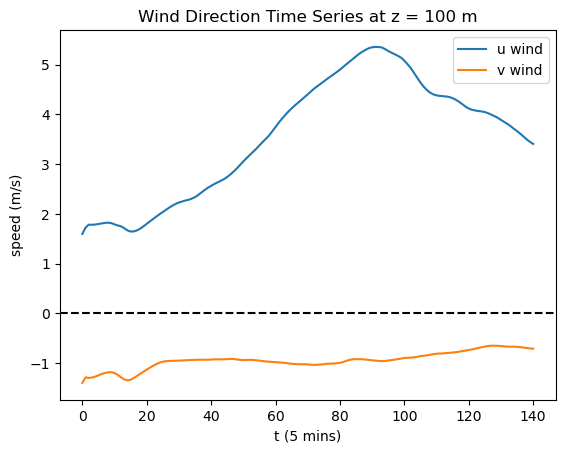

In [39]:
u_t=np.mean(u_data[:,1],axis=(1,2))
v_t=np.mean(v_data[:,1],axis=(1,2))

plt.plot(u_t,label='u wind')
plt.plot(v_t,label='v wind')
plt.xlabel('t (5 mins)'); plt.ylabel('speed (m/s)')
plt.legend()
plt.title('Wind Direction Time Series at z = 100 m')

plt.axhline(color='k',linestyle='dashed')

In [34]:
u_horiz=np.mean(u_data[:,1],axis=(0))
v_horiz=np.mean(v_data[:,1],axis=(0))

Text(0.5, 0.98, '(X,Y) Wind Direction  at z = 100 m')

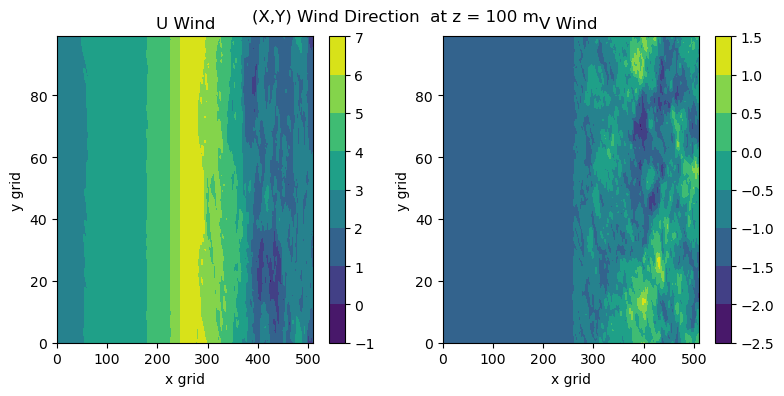

In [37]:
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, figure=fig)
# First plot
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(u_horiz, cmap='viridis')
fig.colorbar(contour1, ax=ax1, orientation='vertical')
ax1.set_title("U Wind")
ax1.set_xlabel('x grid');ax1.set_ylabel('y grid')

# Second plot
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(v_horiz, cmap='viridis')
fig.colorbar(contour2, ax=ax2, orientation='vertical')
ax2.set_title("V Wind ")
ax2.set_xlabel('x grid');ax2.set_ylabel('y grid')

# Adjust layout
fig.tight_layout()

fig.suptitle('(X,Y) Wind Direction  at z = 100 m')

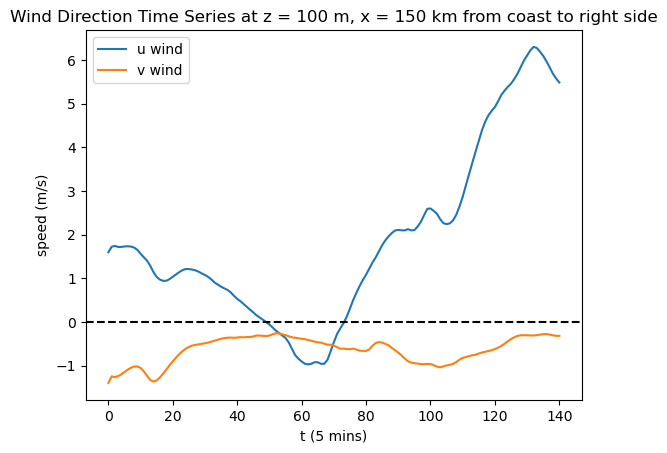

In [43]:
#Focusing on right side of domain
u_t=np.mean(u_data[:,1,:,400:],axis=(1,2))
v_t=np.mean(v_data[:,1,:,400:],axis=(1,2))

plt.plot(u_t,label='u wind')
plt.plot(v_t,label='v wind')
plt.xlabel('t (5 mins)'); plt.ylabel('speed (m/s)')
plt.legend()
plt.title('Wind Direction Time Series at z = 100 m, x = 150 km from coast to right side')
plt.axhline(color='k',linestyle='dashed')

In [44]:
u_horiz=np.mean(u_data[:,1,:,400:],axis=(0))
v_horiz=np.mean(v_data[:,1,:,400:],axis=(0))

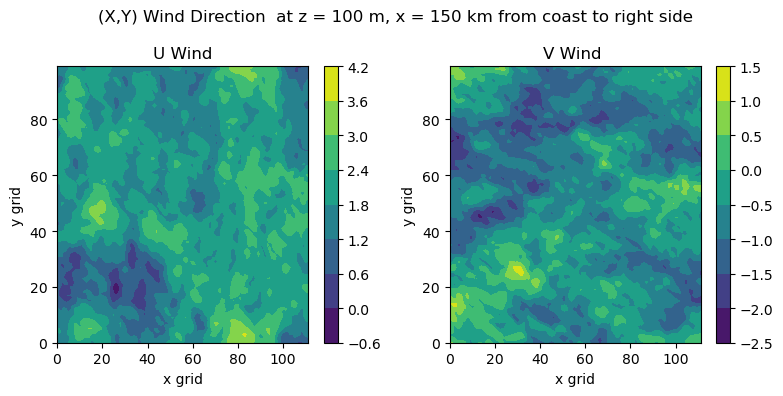

In [47]:
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, figure=fig)
# First plot
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(u_horiz, cmap='viridis')
fig.colorbar(contour1, ax=ax1, orientation='vertical')
ax1.set_title("U Wind")
ax1.set_xlabel('x grid');ax1.set_ylabel('y grid')

# Second plot
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(v_horiz, cmap='viridis')
fig.colorbar(contour2, ax=ax2, orientation='vertical')
ax2.set_title("V Wind ")
ax2.set_xlabel('x grid');ax2.set_ylabel('y grid')

# Adjust layout

fig.suptitle('(X,Y) Wind Direction  at z = 100 m, x = 150 km from coast to right side')
fig.tight_layout()